# Unsupervised Learning with K-Means and PCA

This is a starter notebook for the assignment, as outlined in the accompanying README file.

In [ ]:
#! pip install ucimlrepo

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 309.5 kB/s eta 0:00:30
   -- ------------------------------------- 0.5/9.7 MB 309.5 kB/s eta 0:00:30
   --- ------------------------------------ 0.8/9.7 MB 450.5 kB/s eta 0:00:20
   ---- ----------------------------------- 1.0/9.7 MB 537.6 kB/s eta 0:00:17
   ----- ---------------------------------- 1.3/9.7 MB 638.1 kB/s eta 0:00:14
   ----- ---------------------------------- 1.3/9.7 MB 638.1 kB/s eta 0:00:14
   ------ --------------------------------- 1.6/9.7 MB 686.2 kB/s eta 0:00:12
   ------- ------------------------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import the dataset
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

## Imports

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
X.head()


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


In [11]:
y.value_counts()

Region
3         316
1          77
2          47
Name: count, dtype: int64

## Explore Dataset

In [12]:
X.Channel.value_counts()

Channel
1    298
2    142
Name: count, dtype: int64

In [14]:
# One-hot encode Channel
X_encoded = pd.get_dummies(X, columns=["Channel"], prefix="Channel")

X_encoded = pd.get_dummies(X, columns=["Channel"], prefix="Channel")

# Convert boolean dummies to integers
X_encoded["Channel_1"] = X_encoded["Channel_1"].astype(int)
X_encoded["Channel_2"] = X_encoded["Channel_2"].astype(int)


# Separate features (all now numeric)
X_encoded.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2
0,12669,9656,7561,214,2674,1338,0,1
1,7057,9810,9568,1762,3293,1776,0,1
2,6353,8808,7684,2405,3516,7844,0,1
3,13265,1196,4221,6404,507,1788,1,0
4,22615,5410,7198,3915,1777,5185,0,1


In [16]:
#standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

# Optionally convert back to DataFrame for readability
scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)
scaled_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339,-1.448652,1.448652
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151,-1.448652,1.448652
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293,-1.448652,1.448652
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411,0.690297,-0.690297
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347,-1.448652,1.448652


## Dimensionality Reduction (PCA)

### 1. Applying PCA

In [17]:
pca = PCA()
X_pca = pca.fit_transform(scaled_df)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

### 2. Scree Plot (Variance Explained by Each Component)

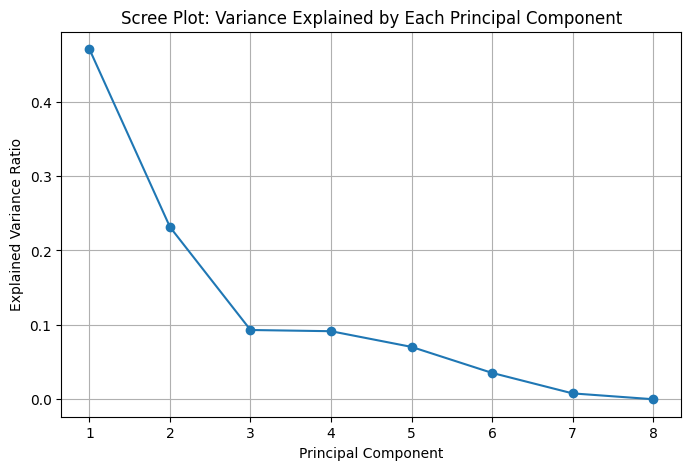

In [18]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot: Variance Explained by Each Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1,len(explained_variance)+1))
plt.grid(True)
plt.show()

Based on this plot, it would be wise to keep the first 2 or 3 components:

If we keep 2 components: We capture roughly 70% of the total variance.

If we keep 3 components: We capture roughly 80% of the total variance.

By choosing the first 3 components, we'd reduce our dataset from 8 variables down to 3 while still retaining the vast majority of the original information.


### 3. Cumulative Variance Plot

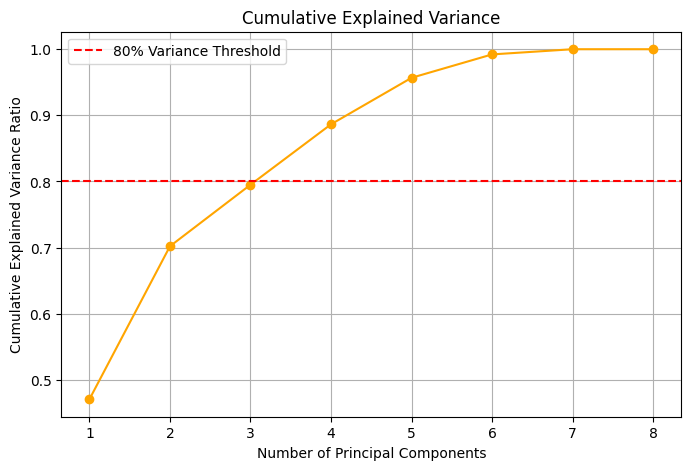

In [19]:
plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance)+1), cumulative_variance, marker='o', color='orange')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.xticks(range(1,len(cumulative_variance)+1))
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Variance Threshold')
plt.legend()
plt.grid(True)
plt.show()

The goal of PCA is dimensionality reduction.

From 1 to 3 components: 

The line climbs very quickly. We are gaining a lot of information for every component we add.

After 3 components: 

The line begins to flatten out. While adding a 4th or 5th component does add information, the "bang for our buck" decreases. We'd be making your data more complex (adding more columns) for relatively small gains in accuracy.

By choosing 3 components, we are likely reducing your dataset from 8 variables down to 3.
This simplifies our model, speeds up training time, and helps prevent overfitting, all while still retaining 80% of the original patterns found in our data.


## Clustering (KMeans)

In [20]:
k_values = range(2,11)

inertia = []
silhouette_scores = []

for k in k_values:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    labels = kmeans.fit_predict(scaled_df)
    
    inertia.append(kmeans.inertia_)
    
    silhouette_scores.append(silhouette_score(scaled_df, labels))

### 1. Inertia (SSE)

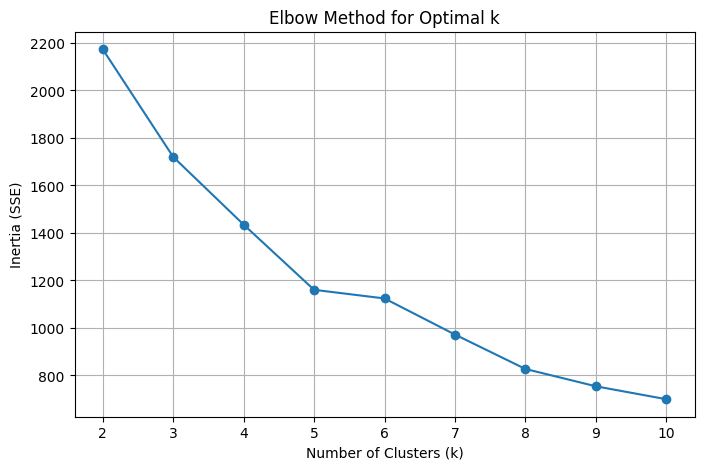

In [21]:
plt.figure(figsize=(8,5))

plt.plot(k_values, inertia, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for Optimal k")

plt.grid(True)

plt.show()

### 2. Silhouette Score

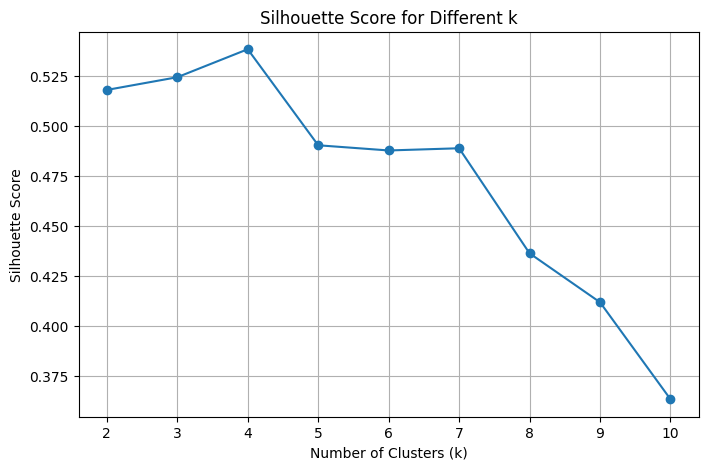

In [22]:
plt.figure(figsize=(8,5))

plt.plot(k_values, silhouette_scores, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")

plt.grid(True)

plt.show()

Based on this Silhouette Score plot combined with our previous Elbow plot, the optimal number of clusters is 4.
While our previous Elbow plot suggested k = 5 (where inertia levels off), the Silhouette Score provides a more "refined" look at how well-separated and cohesive our clusters actually are.

Why 4 is the best choice:
Highest Peak: In a Silhouette plot, the highest point represents the value where data points are most similar to their own cluster and most distinct from neighboring clusters. That peak occurs clearly at (with a score of nearly 0.54).

The "Conflict" with the Elbow Plot: We noticed the score drops significantly at k = 5. This suggests that while k=5 reduces the total error (inertia), it likely forces the data into clusters that are overlapping or too close together, making them less distinct.

Cluster Quality: A score above 0.5 generally indicates a "reasonable" structure has been found. At k = 4 , we have the best balance between having enough clusters to explain the data and ensuring those clusters are high-quality and clearly defined.


## Compare Clustering Performance: Raw vs PCA-Reduced Data

In [23]:
# KMeans on original data
kmeans_raw = KMeans(n_clusters=4, random_state=42)

labels_raw = kmeans_raw.fit_predict(scaled_df)

# Silhouette score
silhouette_raw = silhouette_score(scaled_df, labels_raw)

print("Silhouette Score (Raw Data):", silhouette_raw)

Silhouette Score (Raw Data): 0.5384286904768366


In [25]:
#Kmeans on PCA-Reduced Data

pca = PCA(n_components=3)

X_pca = pca.fit_transform(scaled_df)

kmeans_pca = KMeans(n_clusters=4, random_state=42)

labels_pca = kmeans_pca.fit_predict(X_pca)

silhouette_pca = silhouette_score(X_pca, labels_pca)

print("Silhouette Score (PCA Data):", silhouette_pca)

Silhouette Score (PCA Data): 0.6175579677179774


In [26]:
#Comparison
comparison = pd.DataFrame({
    "Dataset": ["Original Scaled Data", "PCA Reduced Data"],
    "Silhouette Score": [silhouette_raw, silhouette_pca]
})

comparison

,Dataset,Silhouette Score
0,Original Scaled Data,0.538429
1,PCA Reduced Data,0.617558


The clustering performed better on the PCA-reduced dataset, achieving a higher silhouette score of 0.618 compared to 0.538 for the original dataset. This indicates that the clusters formed after dimensionality reduction are more compact and better separated.

PCA removes noise and redundant correlations between features by projecting the data into a smaller set of orthogonal components. This can make the underlying cluster structure more apparent and easier for the KMeans algorithm to detect.

While PCA reduces the dimensionality of the dataset, it retains most of the important variance. In this case, the dimensionality reduction not only simplified the data but also improved cluster separability, resulting in a stronger clustering structure.

Overall, these results suggest that applying PCA before clustering was beneficial for this dataset, as it improved the quality of the clusters while reducing the complexity of the feature space.

## Cluster Visualization

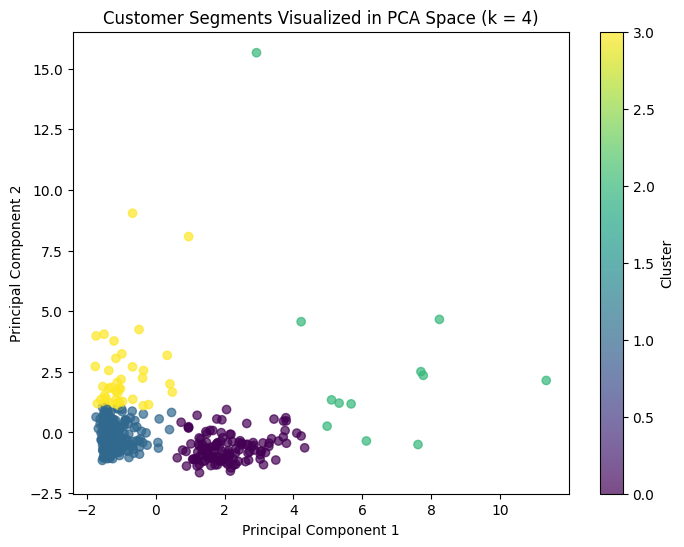

In [27]:
# Reduce to 2 components for visualization
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(scaled_df)

#Fit kmeans on PCA data
kmeans = KMeans(n_clusters=4, random_state=42)

labels = kmeans.fit_predict(X_pca_2)

#plot the clusters
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=labels,
    cmap="viridis",
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("Customer Segments Visualized in PCA Space (k = 4)")

plt.colorbar(label="Cluster")

plt.show()

## Principal Component Interpretation


To interpret the principal components, we examine the PCA loadings, which indicate how strongly each original feature contributes to each principal component.
The magnitude of each loading indicates how strongly a feature contributes to the corresponding component.

In [28]:
# Get PCA loadings
loadings = pd.DataFrame(
    pca_2.components_,
    columns=scaled_df.columns,
    index=["PC1", "PC2"]
)

loadings

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2
PC1,-0.058499,0.392115,0.463692,-0.068562,0.462386,0.106918,-0.446027,0.446027
PC2,0.485536,0.295502,0.100569,0.564438,-0.010742,0.541150,0.166238,-0.166238


**Interpretation of PC1**

The first principal component (PC1) is primarily influenced by:

Grocery (0.464)

Detergents_Paper (0.462)

Milk (0.392)

Channel variables (~±0.446)

These features are typically associated with retail purchasing patterns, where customers buy packaged and household goods in larger quantities.

The strong but opposite loadings for Channel_1 and Channel_2 suggest that this component also captures differences between customer types (Horeca vs Retail).

Therefore, PC1 can be interpreted as a packaged-goods or retail purchasing dimension, separating customers who spend heavily on grocery-related items from those who spend less in these categories.

**Interpretation of PC2**

The second principal component (PC2) is mainly influenced by:

Frozen (0.564)

Delicassen (0.541)

Fresh (0.486)

Milk (0.296)

These variables represent fresh and specialty food purchases, which are often associated with food service businesses such as restaurants, cafes, or hospitality providers.

Therefore, PC2 represents a fresh and perishable food purchasing dimension, distinguishing customers who spend more on fresh and frozen food products.

When the data is projected into the PCA space using PC1 and PC2, the clusters become easier to interpret because these components summarize the main purchasing behaviors in the dataset.

PC1 separates customers based on packaged and household product spending, as well as customer type (Channel).

PC2 separates customers based on fresh and perishable food purchasing patterns.

As a result, the clusters observed in the PCA visualization represent different combinations of retail-oriented purchasing behavior and fresh food purchasing behavior, providing meaningful insight into how customers differ in their spending patterns.

## Cluster Insights


After applying KMeans clustering with k=4, four distinct customer segments were identified based on their purchasing behavior across product categories. 

In [29]:
clustered_df = X_encoded.copy()

clustered_df["Cluster"] = labels
clustered_df["Region"] = y


### Cluster Summary Table
The cluster summary table provides the average spending patterns for each group.

In [31]:
#cluster means
cluster_summary = clustered_df.groupby("Cluster").mean()

cluster_summary

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region
Cluster,,,,,,,,,
0,8165.915385,8748.515385,13905.492308,1441.630769,5991.146154,1535.007692,0.000000,1.000000,2.623077
1,10345.295720,2702.684825,3483.190661,2475.085603,766.000000,943.373541,0.996109,0.003891,2.494163
2,18572.416667,35621.500000,43963.166667,6019.500000,21110.666667,7824.500000,0.083333,0.916667,2.583333
3,32608.585366,7097.609756,6539.268293,11119.682927,946.780488,3293.926829,1.000000,0.000000,2.585366


### The Region distribution provides additional geographic context.

The Region distribution provides additional geographic context.

Although Region was not used in the clustering algorithm, analyzing its distribution across clusters can provide additional insight into how customer behavior varies across geographic areas.


In [30]:
#Region Distribution per Cluster
pd.crosstab(clustered_df["Cluster"], clustered_df["Region"])

Region,1,2,3
Cluster,,,
0,16,17,97
1,51,28,178
2,2,1,9
3,8,1,32


Across all clusters, Region 3 contains the majority of customers, which is consistent with the overall dataset distribution. However, the purchasing behavior across clusters differs significantly.

**Cluster 0 – Retail-Oriented Grocery Buyers**

*Key characteristics*

- High spending on Milk (~8749), Grocery (~13905), and Detergents_Paper (~5991)

- Lower spending on Fresh and Frozen products

- Channel_2 = 1, indicating these customers primarily purchase through retail channels

*Interpretation*

This cluster likely represents retail grocery stores or supermarkets that focus heavily on packaged and household goods such as grocery items and cleaning supplies.

*Regional insight*

Most customers in this cluster are located in Region 3, suggesting strong retail demand in that region.

*Business strategy*

- Focus on bulk supply of packaged goods

- Offer bundle promotions for grocery and household items

- Maintain strong inventory levels for fast-moving consumer goods

**Cluster 1 – Fresh Product Buyers**

*Key characteristics*

- Higher spending on Fresh (~10345) compared to grocery-related products

- Relatively low spending on Detergents_Paper

- Channel_1 ≈ 1, indicating customers mainly purchase through Horeca (Hotel/Restaurant/Café) channels

*Interpretation*

These customers likely represent restaurants, cafes, and food service businesses that require frequent purchases of fresh food products rather than packaged grocery items.

*Regional insight*

This cluster has the largest number of customers, with representation across all regions but again dominated by Region 3.

*Business strategy*

- Ensure consistent supply of fresh produce

- Provide frequent delivery schedules

- Offer fresh-food-focused promotions

**Cluster 2 – Large Wholesale Buyers**

*Key characteristics*

- Extremely high spending across all product categories

- Particularly high spending on Milk (~35621), Grocery (~43963), and Detergents_Paper (~21110)

- Predominantly Channel_2 customers

*Interpretation*

This cluster likely represents large wholesalers or large-scale distributors who purchase in very large quantities.

*Regional insight* 

This is the smallest cluster, indicating that such high-volume customers are relatively rare but potentially very valuable.

*Business strategy*

- Offer premium service and dedicated account management

- Provide volume discounts

- Ensure priority logistics and supply reliability

**Cluster 3 – Fresh Product Specialists**

*Key characteristics*

- Very high spending on Fresh (~32608) and Frozen (~11120)

- Low spending on Grocery and Detergents_Paper

- Channel_1 = 1, meaning these customers are primarily Horeca buyers

*Interpretation*

These customers likely represent food service businesses or specialty food retailers that focus heavily on fresh and frozen products rather than packaged goods.

*Regional insight*

Although smaller than Cluster 1, most customers are again located in Region 3.

*Business strategy*

- Prioritize fresh and frozen product supply chains

- Offer cold-chain logistics solutions

- Provide product bundles tailored for food service businesses

**Overall Business Insights**

The clustering analysis reveals clear differences in purchasing behavior between retail-oriented buyers and Horeca customers. Two main patterns emerge:

***Retail clusters (Cluster 0 and Cluster 2)***

- Higher spending on Grocery and Detergents_Paper

- Primarily purchase through Channel 2

***Horeca clusters (Cluster 1 and Cluster 3)***

- Higher spending on Fresh and Frozen products

- Primarily purchase through Channel 1

Additionally, the majority of customers across all clusters are located in Region 3, suggesting that this region represents the largest and most active market segment.

***These insights can help businesses:***

- Design targeted marketing strategies

- Optimize inventory management

- Improve supply chain logistics

- Develop customer-specific pricing and promotions